In [1]:
import os

import matplotlib as mpl
import numpy as np
import scipy.io as spio
from cil.framework import AcquisitionData, AcquisitionGeometry
from cil.recon import FDK
from cil.utilities.display import show2D
from gvxrPython3 import gvxr
from matplotlib import pyplot as plt
from skimage.measure import profile_line
from utils import (
    find_optimal_stepwedge_size,
    get_optimal_poly_fit,
    setPolySpectrum,
    transmission_to_absorption,
)

# Configure matplotlib graph
font = {
    "family": "serif",
    "size": 15,
}
mpl.rc("font", **font)

# Uncomment the line below to use LaTeX fonts
# matplotlib.rc('text', usetex=True)

# Move all gVXR logs to a file
gvxr.useLogFile("beam-hardening.log")

xpecgen is not install, you won't be able to load a beam spectrum using xpecgen


In [2]:
INPUT_PATH = "../../../data/HelsinkiTomoChallenge"
OUTPUT_PATH = "../../output_data/beam-hardening/"

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

# 1. Read data in

In [3]:
def loadmat(filename):
    """Load .mat file.

    This function should be called instead of direct spio.loadmat as it
    cures the problem of not properly recovering python dictionaries from
    mat files.

    It calls the function ``_check_keys()`` to cure all entries which are
    still mat-objects.
    """
    data = spio.loadmat(filename, struct_as_record=False, squeeze_me=True)

    return _check_keys(data)


def _check_keys(dict):
    """Check if entries in dictionary are mat-objects.

    If yes, ``todict()`` is called to change them to nested dictionaries.
    """
    for key in dict:
        if isinstance(dict[key], spio.matlab.mat_struct):
            dict[key] = _todict(dict[key])

    return dict


def _todict(matobj):
    """Construct from matobjects nested dictionaries."""
    dict = {}

    for strg in matobj._fieldnames:
        elem = matobj.__dict__[strg]
        if isinstance(elem, spio.matlab.mat_struct):
            dict[strg] = _todict(elem)
        else:
            dict[strg] = elem

    return dict


def load_htc2022data(filename, dataset_name="CtDataFull"):
    """Create Acquisition Data from loaded mat file."""
    # Read in matlab file
    mat = loadmat(filename)
    scan_parameters = mat[dataset_name]["parameters"]

    # Read important parameters
    source_center = scan_parameters["distanceSourceOrigin"]
    source_detector = scan_parameters["distanceSourceDetector"]
    pixel_size = scan_parameters["pixelSizePost"]  # Data is binned
    num_dets = scan_parameters["numDetectorsPost"]
    angles = scan_parameters["angles"]

    # Create CIL data from meta data
    ag = (
        AcquisitionGeometry.create_Cone2D(
            source_position=[0, -source_center],
            detector_position=[0, source_detector - source_center],
        )
        .set_panel(
            num_pixels=num_dets,
            pixel_size=pixel_size,
        )
        .set_angles(
            angles=-angles,
            angle_unit="degree",
        )
    )

    # Read data
    scan_sinogram = mat[dataset_name]["sinogram"].astype("float32")

    # Create CIL data
    return AcquisitionData(np.squeeze(scan_sinogram), geometry=ag)


def correct_normalisation(data):
    data_intensity = -data
    data_intensity.exp(out=data_intensity)

    counts, bins = np.histogram(data_intensity.as_array().ravel(), bins=256, range=(0.9, 1.1))

    index = np.argmax(counts)
    peak_value = bins[index]

    data_intensity_fix = data_intensity / peak_value  # Renormalise to set peak to 1
    data_new = data_intensity_fix.log()

    return -data_new

In [4]:
data_path = os.path.join(INPUT_PATH, "htc2022_ta_full.mat")

data_sinogram = loadmat(data_path)["CtDataFull"]["sinogram"]
data_scan_parameters = loadmat(data_path)["CtDataFull"]["parameters"]

aq_data = load_htc2022data(data_path)
aq_data = correct_normalisation(aq_data)

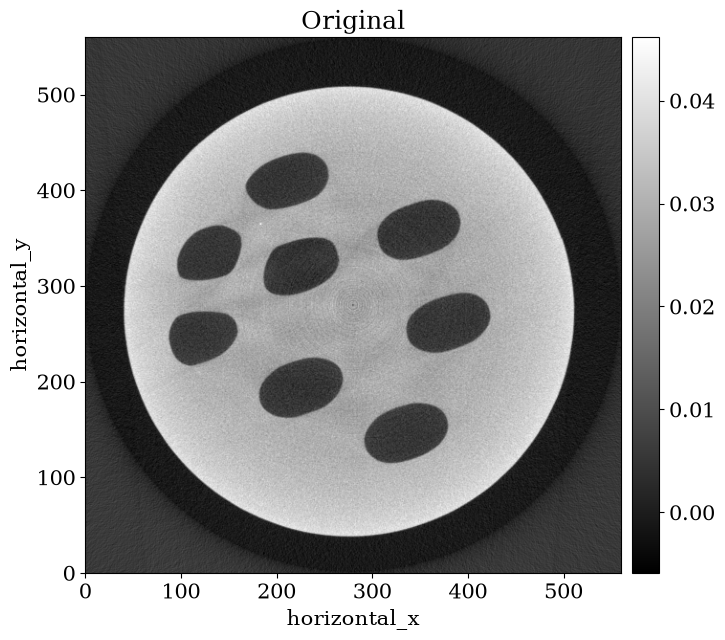

In [5]:
recon_data = FDK(aq_data).run(verbose=0)

show2D(
    recon_data,
    title="Original",
    size=(7.5, 7.5)
)

# 2. Setup the source spectrum and material
To ensure the gVXR simulations match the experimental parameters, configure the settings provided.

In this case, the `.mat` file is extensive enough to cover most of the required data but in the case where the information is not available in the file, the parameters should be input (see `tube_angle_degrees`).

Most importantly, include the material of the sample that most closely resembles the material of the sample being scanned. In the case of the HTC data, this material was Aluminium.

In [6]:
material_of_sample = "Fe"

# ---------------------------------------------------------------
# Units
# ---------------------------------------------------------------
unit_of_length = str(data_scan_parameters["distanceUnit"])
exposure_time_unit = str(data_scan_parameters["exposureTimeUnit"])
tube_voltage_unit = str(data_scan_parameters["voltageUnit"])
tube_current_unit = str(data_scan_parameters["currentUnit"])

# ---------------------------------------------------------------
# Spectrum Characteristics
# ---------------------------------------------------------------
target_material = str(data_scan_parameters["target"])
tube_angle_degrees = float(12)
tube_voltage_kV = float(data_scan_parameters["voltage"])
tube_current = float(data_scan_parameters["current"])
exposure_time = float(data_scan_parameters["exposureTime"])

# ---------------------------------------------------------------
# Filter Characteristics
# ---------------------------------------------------------------
filter_material = str(data_scan_parameters["xRayFilter"])
filter_thickness = float(data_scan_parameters["xRayFilterThickness"])

In [7]:
# ---------------------------------------------------------------
# Geometry specific values
# ---------------------------------------------------------------
# TODO: Use automated reading of data as a future work point
# CIL has specific instructions as to how code can work with
# as flexible gemoetry as possible, so might make automated
# reader quite difficult
scan_geometry = aq_data.geometry.geom_type

# Counted from perpendicular of ray to detector
detector_origin_distance = aq_data.geometry.dist_center_detector
source_origin_distance = aq_data.geometry.dist_source_center

detector_rows, detector_columns = (
    int(data_scan_parameters["detectorRows"] / data_scan_parameters["binningPost"]),
    int(data_scan_parameters["detectorCols"] / data_scan_parameters["binningPost"]),
)

pixel_size = (
    aq_data.geometry.pixel_size_h,
    aq_data.geometry.pixel_size_v,
)

filter_unit = unit_of_length

In [8]:
gvxr.createOpenGLContext()

pci id for fd 126: 10de:1eb1, driver (null)
pci id for fd 127: 10de:1eb1, driver (null)
pci id for fd 126: 10de:1eb1, driver (null)
pci id for fd 127: 10de:1eb1, driver (null)
pci id for fd 126: 10de:1eb1, driver (null)
pci id for fd 127: 10de:1eb1, driver (null)
pci id for fd 126: 10de:1eb1, driver (null)
pci id for fd 127: 10de:1eb1, driver (null)


In [9]:
source_position = (-source_origin_distance, 0, 0)
detector_position = (detector_origin_distance, 0, 0)
detector_up_vector = (0, 0, -1)

# Detector Position and direction
gvxr.setDetectorPosition(*detector_position, unit_of_length)
gvxr.setDetectorUpVector(*detector_up_vector)

gvxr.setDetectorNumberOfPixels(detector_columns, detector_rows)
gvxr.setDetectorPixelSize(*pixel_size, unit_of_length)

# 3. Mirror the polychromatic X-ray source used in reconstruction

In [10]:
poly_spectrum_hist = setPolySpectrum(
    tube_voltage_kV,
    filters=[[filter_material, filter_thickness, filter_unit]],
    tube_angle_in_deg=tube_angle_degrees,
    mAs=300,
    unit="keV",
)

poly_spectrum_bins, poly_spectrum_photons = zip(*poly_spectrum_hist.items(), strict=False)

# Source position
gvxr.setSourcePosition(
    *source_position,
    unit_of_length,
)

# Source type
gvxr.usePointSource()

In [11]:
average_energy = np.sum(np.array(poly_spectrum_photons) * np.array(poly_spectrum_bins)) / np.sum(
    poly_spectrum_photons
)

In [12]:
detector_width, detector_height = gvxr.getDetectorSize("mm")

step_wedge_name = "step-wedge"
step_wedge_material = material_of_sample
number_of_steps = 50
step_wedge_length = detector_width * 0.6
step_wedge_width = detector_height * 0.6

step_wedge_height = find_optimal_stepwedge_size(
    data_sinogram,
    step_wedge_material,
    tolerance=recon_data.array.max() * 0.01,
    max_iterations=300,
)

step_height = step_wedge_height / number_of_steps

In [13]:
gvxr.removePolygonMeshesFromSceneGraph()

gvxr.makeStepWedge(
    step_wedge_name,
    number_of_steps,  # Number of steps
    step_wedge_length,
    step_wedge_width,
    step_height,
    step_height,
    "mm",
)

gvxr.addPolygonMeshAsOuterSurface(step_wedge_name)

gvxr.setElement(step_wedge_name, step_wedge_material)

gvxr.rotateNode(step_wedge_name, 90, 0, 90)
gvxr.translateNode(
    step_wedge_name,
    0,
    0,
    -step_wedge_height * 0.5,
    "mm",
)

x_ray_poly_image = (
    np.array(gvxr.computeXRayImage(), dtype=np.single) / gvxr.getTotalEnergyWithDetectorResponse()
)

# 4. Get a projection with the equivalent monochromatic energy

In [14]:
gvxr.setMonoChromatic(average_energy, "keV", 1000)

x_ray_mono_image = (
    np.array(gvxr.computeXRayImage(), dtype=np.single) / gvxr.getTotalEnergyWithDetectorResponse()
)

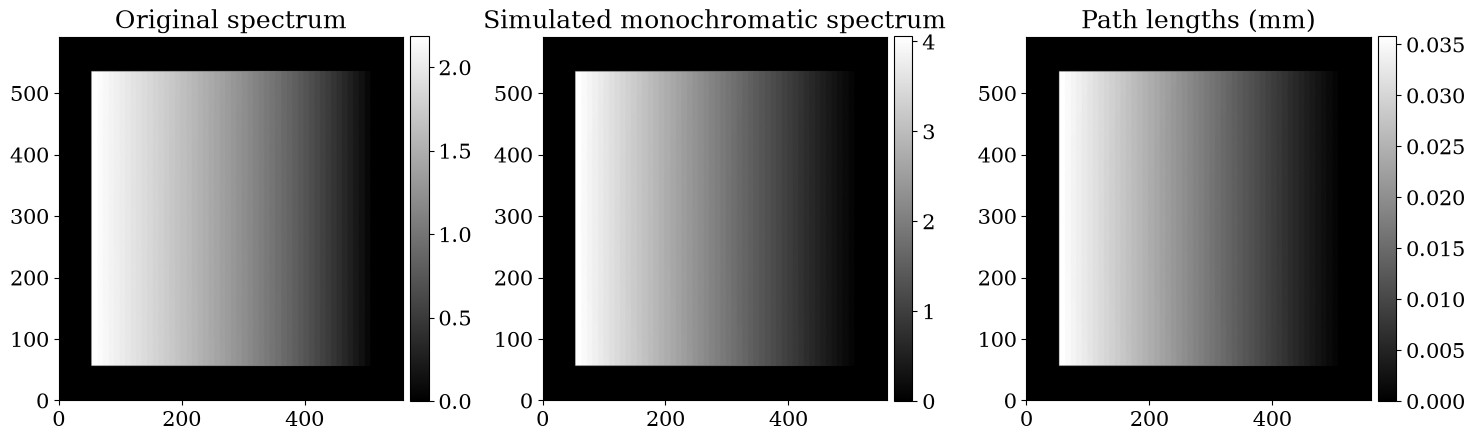

In [15]:
x_ray_L_buffer = np.array(gvxr.getLastLBuffer(), dtype=np.single)           # L-Buffer (path lengths)
x_ray_mono_image_absorption = transmission_to_absorption(x_ray_mono_image)  # Monochromatic source projection
x_ray_poly_image_absorption = transmission_to_absorption(x_ray_poly_image)  # Scan reconstruction

show2D([x_ray_poly_image_absorption, x_ray_mono_image_absorption, x_ray_L_buffer], ["Original spectrum", "Simulated monochromatic spectrum", "Path lengths (mm)"], num_cols = 3)

# 5. Polychromatic fitting of spectra

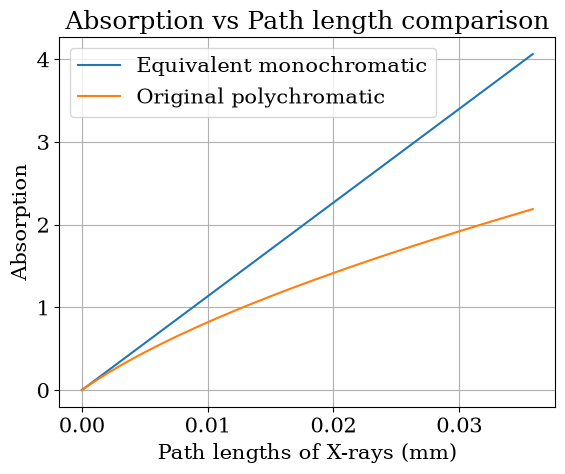

In [16]:
lookup_table_indices = np.argsort(np.ravel(x_ray_poly_image_absorption))
polychromatic_sorted_values = np.ravel(x_ray_poly_image_absorption)[lookup_table_indices]
monochromatic_sorted_values = np.ravel(x_ray_mono_image_absorption)[lookup_table_indices]

L_buffer_sorted_values = np.ravel(x_ray_L_buffer)[lookup_table_indices]

plt.plot(
    L_buffer_sorted_values, monochromatic_sorted_values, label="Equivalent monochromatic"
)
plt.plot(
    L_buffer_sorted_values, polychromatic_sorted_values, label="Original polychromatic"
)
plt.legend()
plt.grid(True)
plt.title("Absorption vs Path length comparison")
plt.xlabel("Path lengths of X-rays (mm)")
plt.ylabel("Absorption")
plt.show()

In [17]:
monochromatic_coefficients = np.polynomial.polynomial.polyfit(
    L_buffer_sorted_values,
    monochromatic_sorted_values,
    1,
)

poly_order_limit = 10

fitted_polychromatic_values = get_optimal_poly_fit(L_buffer_sorted_values, polychromatic_sorted_values, poly_order_limit)

/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly con

# 6. The CIL Beam hardening correction processor

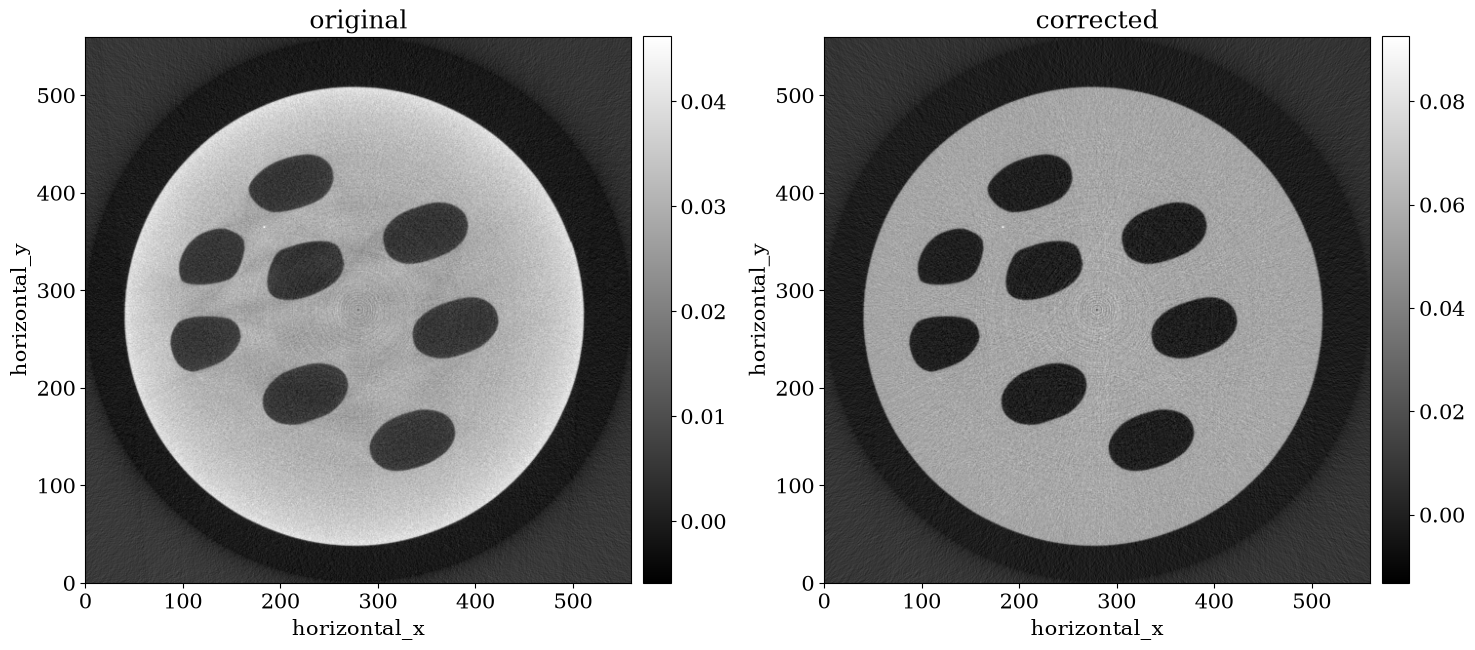

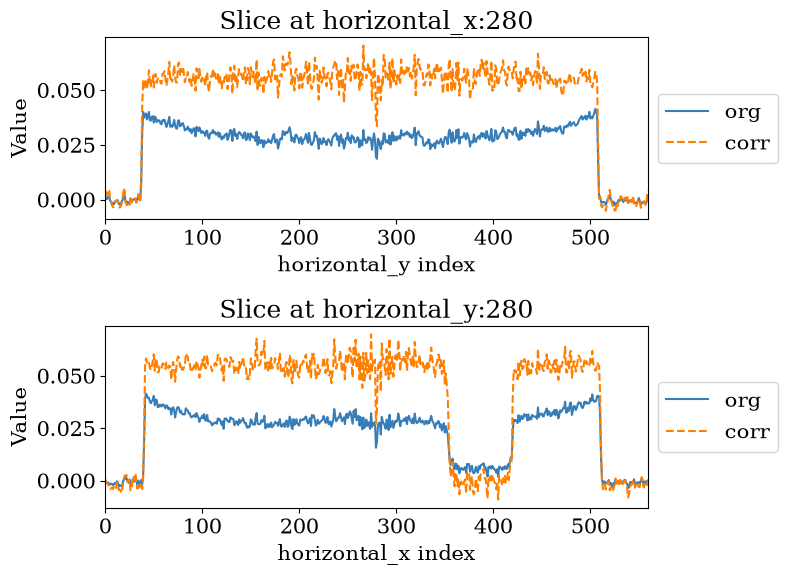

In [18]:
from BeamHardeningCorrector import BeamHardeningCorrector
from cil.utilities.display import show1D, show2D

copy_aq_data = aq_data.copy()

processor = BeamHardeningCorrector(
    fitted_polychromatic_values.coefficients,
    monochromatic_coefficients[1],
    step_wedge_height * 0.1,
    step_wedge_height * 0.001,
)

processor.set_input(copy_aq_data)
corrected_aq_data = processor.get_output()

original_recon_data = FDK(aq_data).run(verbose=0)
corrected_recon_data_1 = FDK(corrected_aq_data).run(verbose=0)

show2D([original_recon_data, corrected_recon_data_1], ["original", "corrected"])
show1D([original_recon_data, corrected_recon_data_1], dataset_labels=["org", "corr"])